# The 1929 Overlay 📉
### Today's chart looks exactly like 1929. So does a coin flip's.

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Shape check: Confirmed](https://img.shields.io/badge/Shape_check-Confirmed-8b949e?style=flat-square)

Every few years the same picture does the rounds: this year's stock market drawn on top of the
months before the 1929 crash, the two lines moving together almost perfectly, a correlation of
0.9-something in the corner. Nobody has to say what comes next.

> 📓 **This is the plain-language layer.** The full sweep, the corrections for having looked
> 126 times and the richer random-walk nulls are in
> **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**. Numbers quoted in the text come from
> the fingerprinted run in [`docs/results.md`](../docs/results.md).
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
plt.rcParams["figure.dpi"] = 80
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from overlay import data, strategy as st
RED, GREY, BLUE, GREEN, AMBER = "#c0392b", "#8b949e", "#1f6feb", "#2ea44f", "#dab617"

## The answer first 🎯

| Question | Answer |
|---|---|
| Does today's chart often look like 1929? | Yes — **29%** of months since 1931 match the 1927-29 run-up at 0.9 or better. |
| Is a 0.9 match rare? | No. Search the past of a pure random walk and you find one **about half** the time. |
| Did a crash follow the 1929 look-alikes? | Barely more often than usual: 5.3% vs 4.3% fell 20% within a year. |
| Does forecasting from look-alikes work? | No: no skill out of sample on 69 years of monthly or 23 years of daily data. |
| Can you trade it? | No: it trails simply holding the market on both tapes. |

## 1 · The claim

Here is the chart, built from real data: the US stock market (total return, dividends
reinvested) over the 24 months to January 2014, laid over the 24 months to August 1929. An
overlay of exactly this kind circulated widely in early 2014.

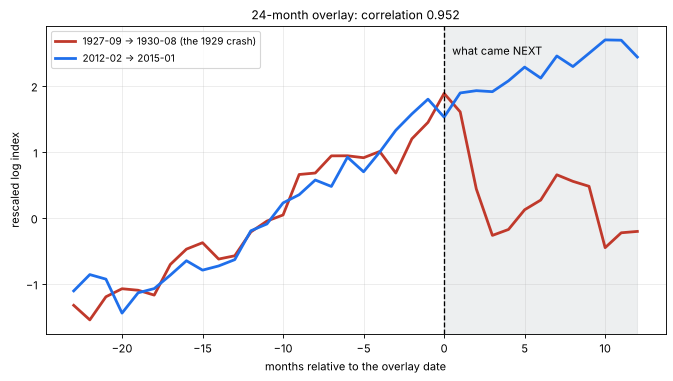

next 12 months after Aug 1929: -32.4%
next 12 months after Jan 2014: +12.0%


In [2]:
m = data.load_monthly()          # REAL tape: Fama-French US market, monthly TOTAL return
lp = m["logp"]
def window(end, n=24, after=0):
    i = lp.index.get_loc(pd.Timestamp(end))
    return lp.iloc[i - n + 1: i + 1 + after]
a = window("1929-08-31", after=12)
b = window("2014-01-31", after=12)
za = (a.iloc[:24] - a.iloc[:24].mean()) / a.iloc[:24].std()
zb = (b.iloc[:24] - b.iloc[:24].mean()) / b.iloc[:24].std()
corr = np.corrcoef(a.iloc[:24], b.iloc[:24])[0, 1]
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(-23, 13)
ax.plot(x, (a - a.iloc[:24].mean()) / a.iloc[:24].std(), color=RED, lw=2.5,
        label="1927-09 → 1930-08 (the 1929 crash)")
ax.plot(x, (b - b.iloc[:24].mean()) / b.iloc[:24].std(), color=BLUE, lw=2.5,
        label="2012-02 → 2015-01")
ax.axvline(0, color="k", lw=1.2, ls="--")
ax.axvspan(0, 12, color=GREY, alpha=0.15)
ax.text(0.5, ax.get_ylim()[1] * 0.85, "what came NEXT", fontsize=10)
ax.set_xlabel("months relative to the overlay date"); ax.set_ylabel("rescaled log index")
ax.set_title(f"24-month overlay: correlation {corr:.3f}", fontsize=11)
ax.legend(fontsize=9); plt.show()
print(f"next 12 months after Aug 1929: {np.expm1(a.iloc[-1] - a.iloc[23]):+.1%}")
print(f"next 12 months after Jan 2014: {np.expm1(b.iloc[-1] - b.iloc[23]):+.1%}")

A correlation of 0.95 sounds like proof. The question this notebook keeps asking is the one the
chart never does: **compared to what?**

## 2 · So what?

If the shape of the recent past told you what comes next, it would be the most valuable
indicator in finance: a free crash detector, from nothing but a price chart. It would also mean
markets repeat themselves in a way that thousands of professional investors somehow fail to
exploit. Either claim deserves a test before it deserves a reaction.

## 3 · How we'd know

We turn the chart into a machine that can be scored. **At every month**, it looks only at the
past, finds the five stretches of history whose shape best matches the last two years, and
predicts that the next year will do what followed them, on average. Then we compare those
predictions with what actually happened, from 1950 to 2018, and do the same on daily S&P 500
data from 2000 to 2022.

What would make us say **mirage**, written down before running it: the predictions do no better
than "the market drifts up at its usual rate", the best of the many variants tried stops looking
special once you account for how many were tried, and a pure random walk produces matches just
as impressive as the real ones.

> 🔬 **For the quants.** Newey-West t-statistics for the overlapping 12-month outcomes, Holm
> across 126 combinations, White's Reality Check across every timing rule. Details in notebook 02.

## 4 · The teardown

### 4.1 Two charts that have nothing to do with each other

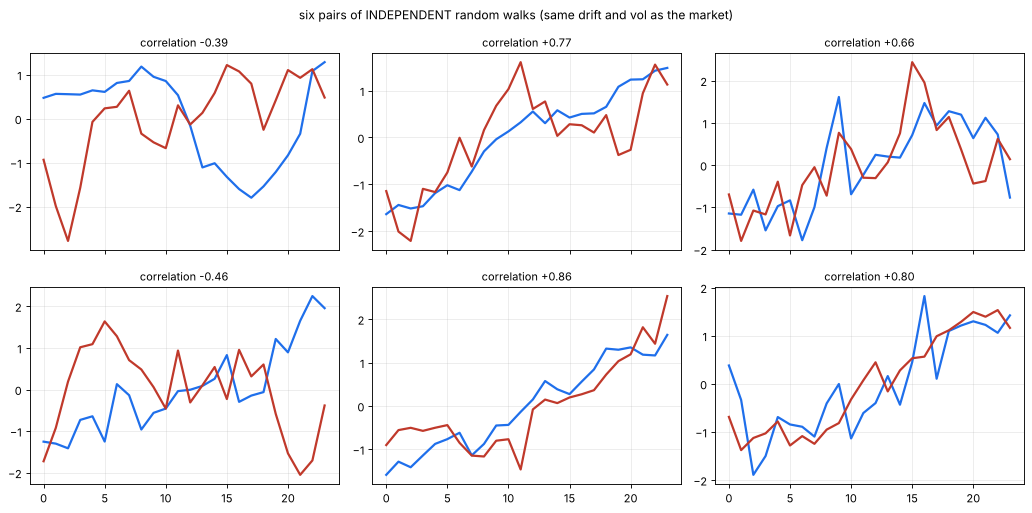

In [3]:
mo = data.tape_moments(m["lr"], 12)   # the REAL tape's drift and volatility
rng = np.random.default_rng(29)
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5), sharex=True)
for ax in axes.ravel():
    p1 = np.cumsum(mo["mu"] + mo["sigma"] * rng.standard_normal(24))
    p2 = np.cumsum(mo["mu"] + mo["sigma"] * rng.standard_normal(24))
    c = np.corrcoef(p1, p2)[0, 1]
    ax.plot((p1 - p1.mean()) / p1.std(), color=BLUE, lw=2)
    ax.plot((p2 - p2.mean()) / p2.std(), color=RED, lw=2)
    ax.set_title(f"correlation {c:+.2f}", fontsize=10)
fig.suptitle("six pairs of INDEPENDENT random walks (same drift and vol as the market)",
             fontsize=11)
plt.tight_layout(); plt.show()

Every pair above is two coin-flipping machines that never saw each other. Yet some of them
"track" convincingly. The reason is simple: **anything that trends correlates with anything else
that trends.** Two lines that both go up are correlated, whatever made them go up.

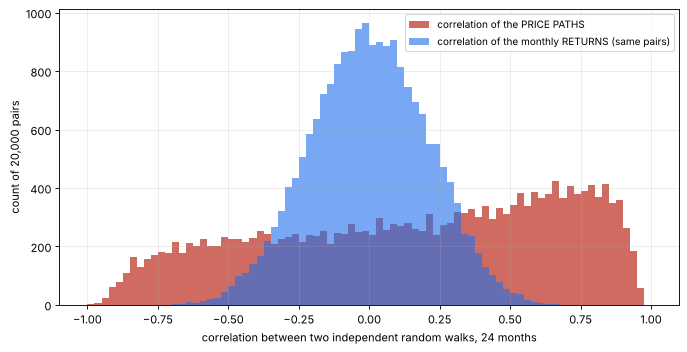

price paths above 0.7: 17.9%   above 0.9: 2.5%
returns above 0.5:     0.59%


In [4]:
p = st.pair_correlation_null(24, mo["mu"], mo["sigma"], n_sims=20000)
fig, ax = plt.subplots(figsize=(10, 4.8))
bins = np.linspace(-1, 1, 81)
ax.hist(p["price"], bins=bins, color=RED, alpha=0.75, label="correlation of the PRICE PATHS")
ax.hist(p["returns"], bins=bins, color=BLUE, alpha=0.6,
        label="correlation of the monthly RETURNS (same pairs)")
ax.set_xlabel("correlation between two independent random walks, 24 months")
ax.set_ylabel("count of 20,000 pairs"); ax.legend(fontsize=9); plt.show()
print(f"price paths above 0.7: {p['p_price_gt_07']:.1%}   above 0.9: {p['p_price_gt_09']:.1%}")
print(f"returns above 0.5:     {p['p_returns_gt_05']:.2%}")

The red spread is what overlay charts measure. The blue spike is what actually carries
information — the month-by-month moves — and there, unrelated series look unrelated.

### 4.2 Now let the chartist *search*

One pair rarely hits 0.9. But the overlay chart is never one pair: someone looked through a
century of history and picked the stretch that fits best. Do that to a random walk:

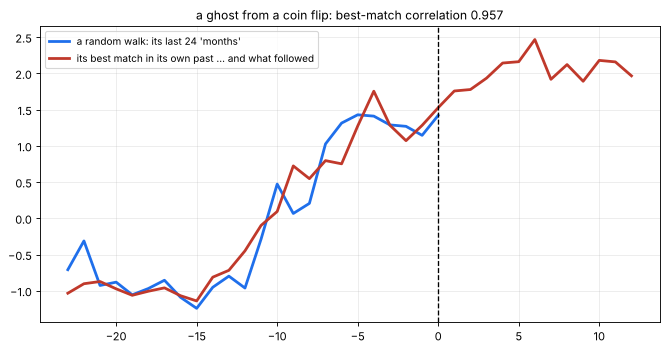

searching 92 years of a random walk: median best match 0.906; above 0.9 in 52% of walks


In [5]:
rw = st.random_walk_paths(1, len(m), mo["mu"], mo["sigma"], seed=7)[0]
s = st.analogue_search(rw, 24, [len(rw) - 1], k_max=1)
e = int(s["ends"][0, 0]); c = s["corr"][0, 0]
q = rw[-24:]; h_ = rw[e - 23: e + 13]
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(np.arange(-23, 1), (q - q.mean()) / q.std(), color=BLUE, lw=2.5,
        label="a random walk: its last 24 'months'")
ax.plot(np.arange(-23, 13), (h_ - h_[:24].mean()) / h_[:24].std(), color=RED, lw=2.5,
        label="its best match in its own past ... and what followed")
ax.axvline(0, color="k", ls="--", lw=1.2)
ax.set_title(f"a ghost from a coin flip: best-match correlation {c:.3f}", fontsize=11)
ax.legend(fontsize=9); plt.show()
b = st.best_match_null(len(m), 24, mo["mu"], mo["sigma"], n_sims=300)
print(f"searching 92 years of a random walk: median best match {np.median(b):.3f}; "
      f"above 0.9 in {np.mean(b > 0.9):.0%} of walks")

Searching the past of a pure random walk finds a match above 0.9 **about half** the
time. A 0.9 on an overlay chart is not a discovery; it is what searching produces.

### 4.3 The real market's matches against a random walk's

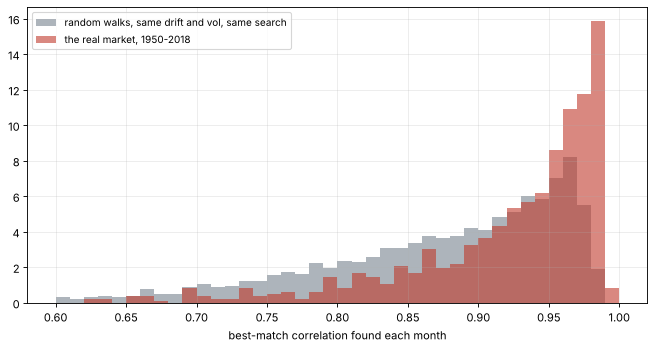

median best match: real 0.946, random walk 0.894


In [6]:
idx = st.eval_positions(m.index, "1950-01-31")
real = st.analogue_search(m["logp"].to_numpy(), 24, idx, k_max=1)["corr"][:, 0]
null = st.null_search_distribution(len(m), 24, mo["mu"], mo["sigma"], idx, n_sims=8)
fig, ax = plt.subplots(figsize=(10, 4.8))
bins = np.linspace(0.6, 1.0, 41)
ax.hist(null.ravel(), bins=bins, density=True, color=GREY, alpha=0.7,
        label="random walks, same drift and vol, same search")
ax.hist(real, bins=bins, density=True, color=RED, alpha=0.6, label="the real market, 1950-2018")
ax.set_xlabel("best-match correlation found each month"); ax.legend(fontsize=9); plt.show()
print(f"median best match: real {np.median(real):.3f}, random walk {np.median(null):.3f}")

The real market's matches are a shade tighter than a plain random walk's — and in notebook 02
most of that gap disappears once the random walk is allowed to be calm and stormy at the same
times the real market was. Either way, both sit up near 0.9: impressive-looking matches are the
normal state of affairs.

> 🔬 **For the quants.** Real 0.946, Gaussian walk 0.903, a walk
> with the real volatility path 0.919, a 6-month block bootstrap of the real
> returns 0.931.

### 4.4 The 1929 chart, scored month by month since 1931

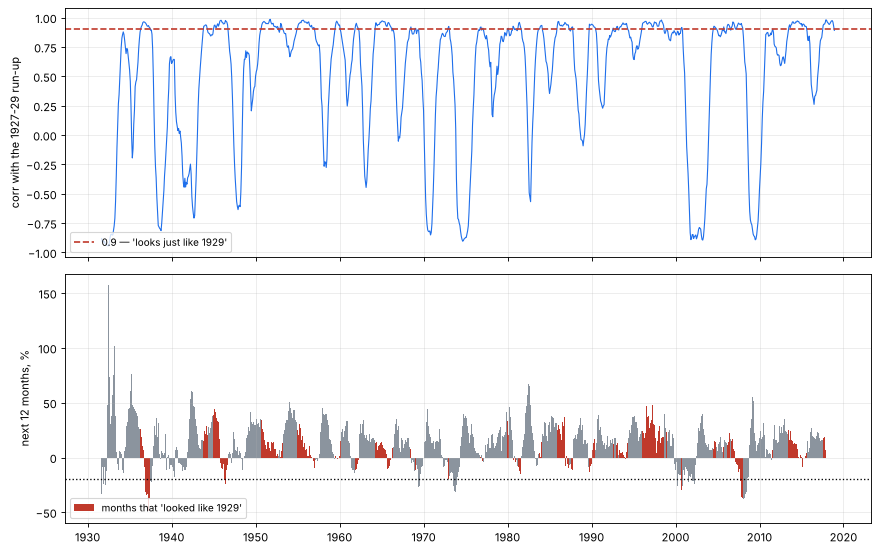

match >= 0.9: 29% of months | fell 20%+ within a year: 5.3% (vs 4.3% for all months)
match >= 0.95: 10% of months | fell 20%+ within a year: 5.0% (vs 4.3% for all months)


In [7]:
ov = st.template_overlay(m["logp"], "1929-08-31", 24, 12)
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(ov.index, ov["corr"], color=BLUE, lw=1)
axes[0].axhline(0.9, color=RED, ls="--", lw=1.5, label="0.9 — 'looks just like 1929'")
axes[0].set_ylabel("corr with the 1927-29 run-up"); axes[0].legend(fontsize=9, loc="lower left")
hi = ov["corr"] >= 0.9
axes[1].bar(ov.index[~hi], np.expm1(ov["fwd"][~hi]) * 100, width=31, color=GREY)
axes[1].bar(ov.index[hi], np.expm1(ov["fwd"][hi]) * 100, width=31, color=RED,
            label="months that 'looked like 1929'")
axes[1].axhline(-20, color="k", ls=":", lw=1.2)
axes[1].set_ylabel("next 12 months, %"); axes[1].legend(fontsize=9, loc="lower left")
plt.tight_layout(); plt.show()
for th in (0.9, 0.95):
    e = st.overlay_episodes(ov, th)
    print(f"match >= {th}: {e['share_match']:.0%} of months | fell 20%+ within a year: "
          f"{e['crash_rate_match']:.1%} (vs {e['crash_rate_all']:.1%} for all months)")

"Looks like 1929" is a description of **29%** of all months since 1931 —
any strong two-year rally does. The red bars sit above the dotted −20% line almost exactly as
often as the grey ones. Those months did go on to earn less than average
(+5.9% vs +11.2% a year), but that is mostly "after a big rally, returns
cool off", not a crash: once the size of the rally is accounted for, the 1929 shape adds little.

### 4.5 The forecasting machine, scored

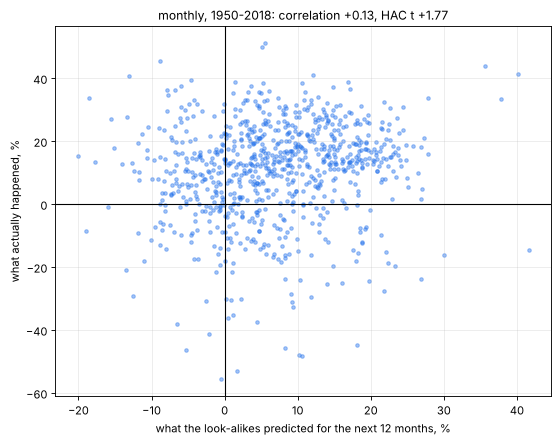

In [8]:
H = st.HEADLINE_MONTHLY
logp = m["logp"].to_numpy()
s = st.analogue_search(logp, H["L"], idx, k_max=H["k"], gap=H["L"])
fc = st.analogue_forecast(logp, s, H["h"], H["k"])
y = st.realised_forward(logp, idx, H["h"])
ev = st.evaluate_forecast(fc, y, st.historical_drift_forecast(logp, idx, H["h"]), H["h"])
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(fc * 100, y * 100, s=10, alpha=0.4, color=BLUE)
ax.axhline(0, color="k", lw=1); ax.axvline(0, color="k", lw=1)
ax.set_xlabel("what the look-alikes predicted for the next 12 months, %")
ax.set_ylabel("what actually happened, %")
ax.set_title(f"monthly, 1950-2018: correlation {ev['corr']:+.2f}, HAC t {ev['t']:+.2f}",
             fontsize=11)
plt.show()

A cloud. The predictions explain essentially nothing about what followed, and they are worse
than simply assuming the market's long-run average (out-of-sample R² −21.6%). The one
variant out of 126 that looked best is no better than what you would expect to
find by chance among that many tries.

### 4.6 The control: when the past *does* repeat, the machine sees it

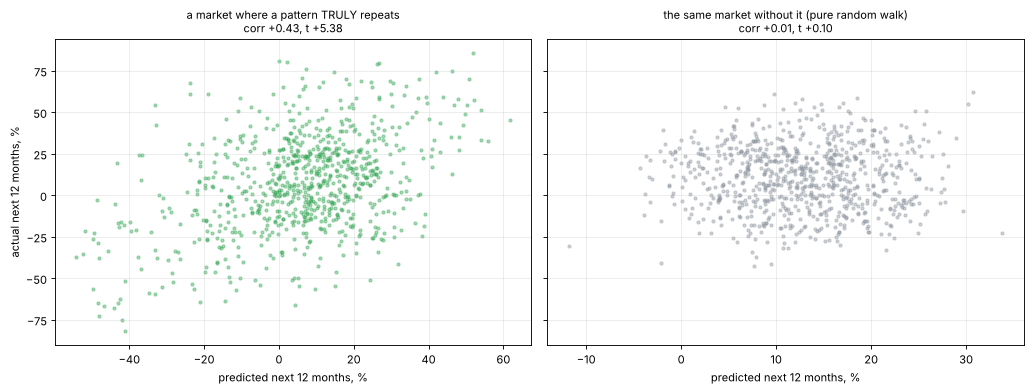

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, s_, ttl in ((axes[0], 1.0, "a market where a pattern TRULY repeats"),
                    (axes[1], 0.0, "the same market without it (pure random walk)")):
    tape, truth = data.synthetic_tape(signal_strength=s_, seed=1015)  # SYNTHETIC
    lp_ = tape["logp"].to_numpy()
    ix = st.eval_positions(tape.index, "1950-01-31")
    ss = st.analogue_search(lp_, 24, ix, k_max=5, gap=24)
    f_ = st.analogue_forecast(lp_, ss, 12, 5); y_ = st.realised_forward(lp_, ix, 12)
    e_ = st.evaluate_forecast(f_, y_, st.historical_drift_forecast(lp_, ix, 12), 12)
    ax.scatter(f_ * 100, y_ * 100, s=8, alpha=0.4, color=GREEN if s_ else GREY)
    ax.set_title(f"{ttl}\ncorr {e_['corr']:+.2f}, t {e_['t']:+.2f}", fontsize=10)
    ax.set_xlabel("predicted next 12 months, %")
axes[0].set_ylabel("actual next 12 months, %")
plt.tight_layout(); plt.show()

In a synthetic market where a distinctive shape really is always followed by the same fall, the
same machine finds it easily. So the method is not broken. The real market simply does not
contain what the chart implies it does.

## 5 · The verdict

**Signal: None.** The pre-registered monthly forecaster (24-month match, 5
analogues, 12-month forecast, 1950-2018 out of sample) has a Newey-West t of **+1.77**
and an out-of-sample R² of −21.6% against the plain historical drift; the daily S&P 500
version gives t **−1.63**. Across all **126 combinations** tried,
5 (4%) were raw-significant — chance gives 5% — and the
best Holm-adjusted p is **1.00**. The one number that survives a two-sided
correction points the *wrong* way (daily price path, L=63, h=63, k=5, t −4.31).

**Tradability: Mirage.** Going to cash when the analogues forecast a loss (one period
of lag, 10 bp one-way): net excess Sharpe **0.47 vs 0.52** for
buy-and-hold monthly, **0.22 vs 0.34** daily; White's Reality Check over
every rule, p = 1.00 and 1.00.

**Shape check: Confirmed.** Real history matches itself a shade better than a random walk
(median best match 0.946 vs 0.903), mostly because of volatility
clustering (0.919 with the real volatility path, 0.931 for a
6-month block bootstrap). The shapes rhyme; what follows them does not.

## 6 · Could you trade it?

The simplest trade: be in the market when the look-alikes predict gains, in cash when they
predict losses, acting a month after the signal and paying a small cost each switch. Over
1950-2018 it earned a risk-adjusted return (Sharpe ratio, over cash) of **0.47**,
against **0.52** for simply staying invested; on daily data since 2000,
**0.22** against **0.34**. Testing every variant at once (White's Reality
Check) gives p = 1.00: none of them beats doing nothing.

## 7 · Going further 🚪

- **Next time you see the overlay**, ask for two numbers it never shows: how often today's chart
  matches *any* old rally that well, and what followed all of those matches, not just the one
  that crashed.
- **The shape is mostly the size of the rally.** A strong two-year run matches 1929 because 1929
  was a strong two-year run. Whether returns cool after big rallies is a real, old and contested
  question — a different study from this one.
- **One odd corner of the grid predicts backwards** on daily data (notebook 02, §7). It came out
  of a search, so it is a lead for someone to test on fresh data, not a strategy.
- Fork it: swap in a different distance (dynamic time warping, Euclidean on scaled paths), a
  different template (1987, 2000) or another market. The random-walk null in `overlay.strategy`
  works for any of them.